In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, RocCurveDisplay)

In [41]:
df = pd.read_csv('heart.csv')
def resumetable(df):
    print(f"data shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns = ['data type'])
    summary = summary.reset_index()
    summary = summary.rename(columns = {"index": "feature"})
    summary["Num_Null"] = df.isnull().sum().values
    summary["Num_Unique"] = df.nunique().values
    summary["First_Value"] = df.loc[0].values
    summary["Second_Value"] = df.loc[1].values
    summary["Third_Value"] = df.loc[2].values
    
    return summary
resumetable(df)

data shape: (918, 12)


,feature,data type,Num_Null,Num_Unique,First_Value,Second_Value,Third_Value
0,Age,int64,0,50,40,49,37
1,Sex,object,0,2,M,F,M
2,ChestPainType,object,0,4,ATA,NAP,ATA
3,RestingBP,int64,0,67,140,160,130
4,Cholesterol,int64,0,222,289,180,283
5,FastingBS,int64,0,2,0,0,0
6,RestingECG,object,0,3,Normal,Normal,ST
7,MaxHR,int64,0,119,172,156,98
8,ExerciseAngina,object,0,2,N,N,N
9,Oldpeak,float64,0,53,0.0,1.0,0.0


HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


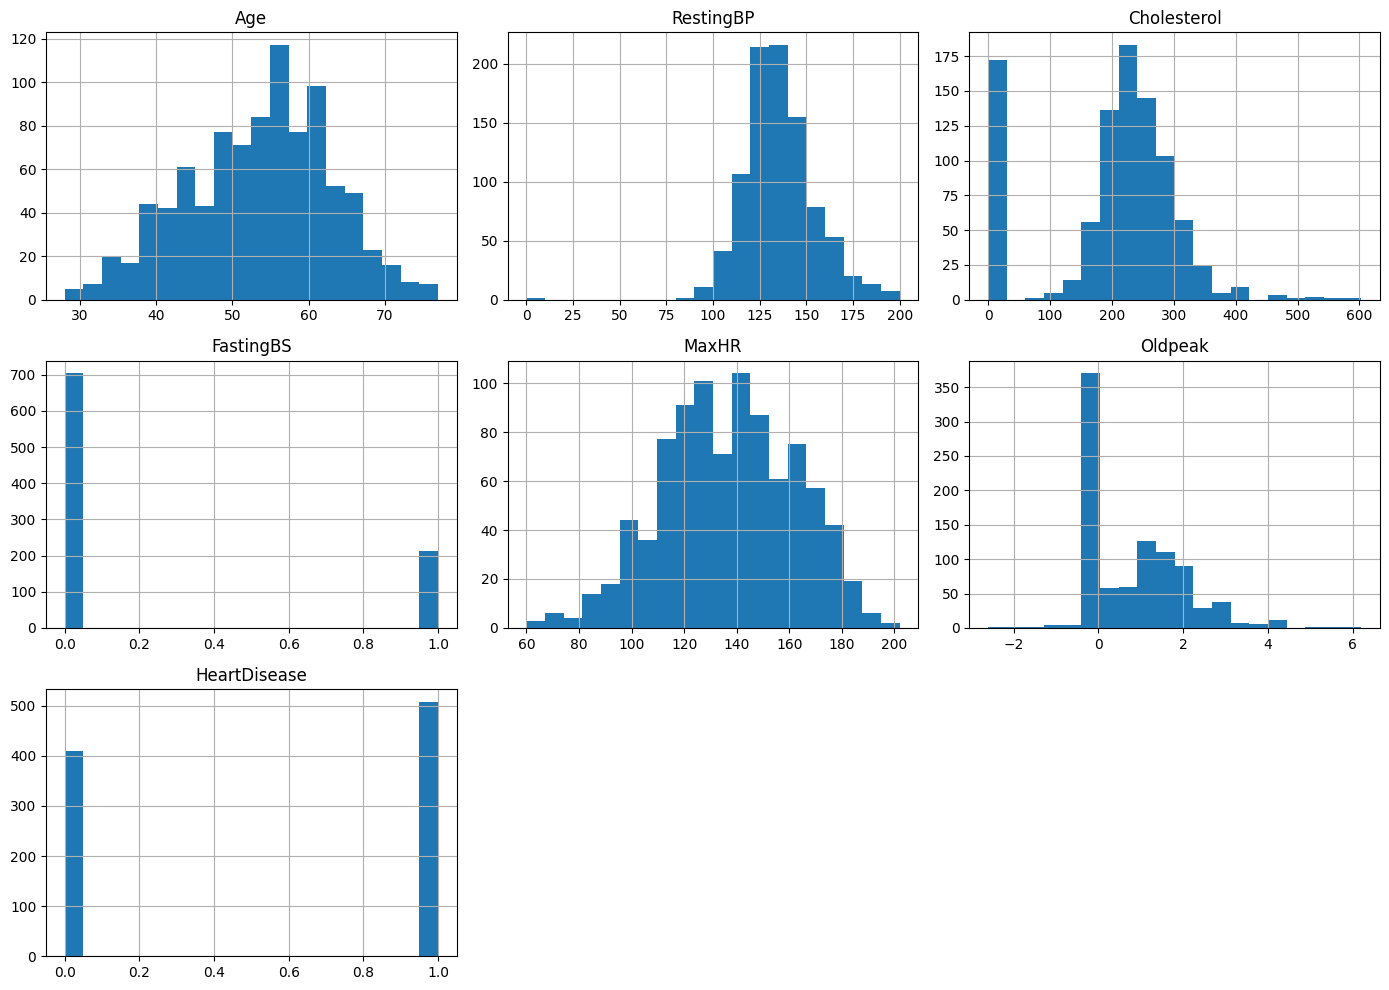

In [42]:
df.describe()
print(df['HeartDisease'].value_counts(normalize=True))
df.hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()
median_bp = df.loc[df['RestingBP'] != 0, 'RestingBP'].median()
df['RestingBP'] = df['RestingBP'].replace(0, median_bp)
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df = pd.get_dummies(df, columns=cat_features, drop_first=True)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
clf_gmm = GaussianMixture(n_components=1, random_state=0)
clf_gmm.fit(X)
pdf_values = np.exp(clf_gmm.score_samples(X))
threshold = np.quantile(pdf_values, 0.02)
outlier_mask = pdf_values <= threshold
X = X[~outlier_mask]
y = y[~outlier_mask]
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [43]:
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print(f"Top selected features: {list(selected_features)}")

Top selected features: ['ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


Training Logistic Regression...
Validation accuracy: 0.811, Best Params: {'C': 0.01}
Training Random Forest...
Validation accuracy: 0.822, Best Params: {'max_depth': None, 'n_estimators': 50}
Training SVC...
Validation accuracy: 0.844, Best Params: {'C': 0.01, 'kernel': 'rbf'}

Best Model: SVC
Validation Accuracy: 0.844
Test Accuracy: 0.833
Precision: 0.783
Recall: 0.959
F1-Score: 0.862
AUC: 0.819


<Figure size 800x600 with 0 Axes>

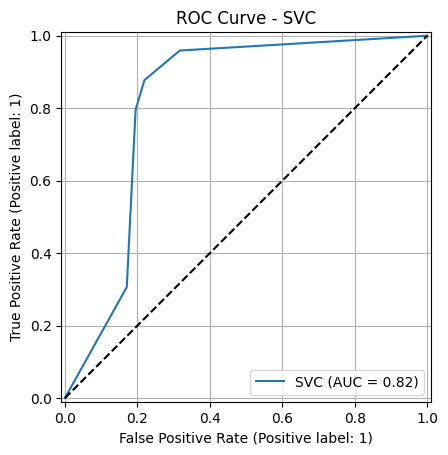

In [46]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

classifiers = [
    LogisticRegression(max_iter=5000),
    RandomForestClassifier(random_state=42),
    SVC(probability=True, random_state=42)
]

parameters = [
    {'C': [0.01, 1, 100]},
    {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]},
    {'kernel': ('linear', 'rbf'), 'C': [0.01, 1, 100]}
]

clf_names = ['Logistic Regression', 'Random Forest', 'SVC']
best_score = -np.inf
best_model = None
best_index = -1

for i in range(len(classifiers)):
    print(f"Training {clf_names[i]}...")
    grid_search = GridSearchCV(classifiers[i], parameters[i], cv=5)
    grid_search.fit(X_train, y_train)
    valid_score = grid_search.best_estimator_.score(X_valid, y_valid)
    print(f"Validation accuracy: {valid_score:.3f}, Best Params: {grid_search.best_params_}")
    if valid_score > best_score:
        best_score = valid_score
        best_model = grid_search.best_estimator_
        best_index = i

print('')
print(f"Best Model: {clf_names[best_index]}")
print(f"Validation Accuracy: {best_score:.3f}")

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.3f}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.3f}")
plt.figure(figsize=(8,6))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.plot([0,1], [0,1], 'k--')
plt.title(f"ROC Curve - {clf_names[best_index]}")
plt.grid()
plt.show()